In [23]:
import pandas as pd
import numpy as np

## **Pandas** 

### **Operador & e |**

Faz a operação de and ou or em todo o vetor para cada posição retornando um novo vetor (necessário manter tudo entre parenteses pois eles tem precedencia sobre outros operadores aritméticos). O and do python já tenta converter tudo em um unico booleano.

### **Operador Serie / Serie**

Faz a divisão vetorizada para cada posição.

### **df.groupby([colunas], as_index=False)**

Agrupa as linhas de acordo com o vetor de colunas. as_index=False evita que o pandas transforme as colunas da lista em indices e mantem elas como colunas normais... se elas fosse indices não seria mais possivel usar ['coluna'] a não ser que seja usado o metodo .reset_index(). Ao usar o groupBy ele retorna um objeto novo chamado DataframeGroupby ou SerieGroupBy que basicamente armazenam os indices de quais grupos cada linha faz parte. Ao realizar uma operação nesse novo objeto essa operação é realizada isoladamente em cada grupo.

### **.agg()**

Muitas linhas -> 1 Linha por grupo, algumas das opções são 'count' que conta valores não nulos, 'size' que conta linhas do grupo (nulos também), ''min', 'max', 'nunique' que conta valores unicos do grupo.

```py
.agg(
    nome_coluna=("coluna agregada", "operação de agregação"),
    media_de_x=("x", "mean"), # media
    agg_custom=("x", lambda x: x.max() - x.min()) # customizado
)
```

Cria agregações para cada grupo e colunas escolhidas caso seja usado em um DataFrameGroupby, caso seja usado em um dataframe normal cria as agregações para o dataframe inteiro para as colunas escolhidas. Caso seja uma Serie cria as agregações para ela mesmo.

### **.transform()**

Posso fazer tudo que .agg faz mas ao invés de comprimir tudo em uma unica linha por grupo, apens replica o valor para todos do grupo

### **.merge(dataframe, how=("left", "inner", "right"), on=)**

Funciona exatamente como o JOIN porém se a chave de join dos 2 dataframes tiverem nomes diferentes é necessário usar os parametros: left_on / right_on, por exemplo se trips tem driver_id mas drivers tem id, o correto é merge(left_on='driver_id', right_on='id')

### **.rank(method=?,ascending=?)**

È um metodo que pode ser aplicado em Series do pandas e retorna uma série nova com o ranking de cada elemento daquela série em ordem crescente ou decrescente. Tem métodos 'dense' que equivale ao DENSE_RANK() do SQL, ou seja, itens iguais tem mesmo rank. Metodo 'min' é equivalente ao RANK(), ou seja, atribui o menor rank e pula 1 rank e por fim metodo 'first' que é equivalente ao ROW_NUMBER() que apenas enumera as linhas sem levar em consideração se são iguais ou não. 

Mesmo sendo um metodo essencialmente de Series, podemos usar diretamente em um Dataframe mas oq retorna é uma matriz com os ranks individuais de cada coluna do Dataframe. Se rank() for usado com DataframesGroupBy (.groupby('x')['y','z']) ou SerieGroupBy('x')['y'], ele fica equivalente ao PARTITION BY do SQL e cria um rank para cada grupo.

### **.sort_values(by=[?,?], ascending=[?,?])**

Ordena uma Série ou Dataframe por um conjunto de colunas no primeiro vetor e sua ordem definida pelo segundo vetor.

### **round(valor, n)**

Arredonda valor para n casas decimais

### **Date Manipulation**

#### **pd.to_datetime(str)**

converte string para datetime/timestamp. Isso é necessário para antes de usar qualquer metodo e etc

####  **(coluna com data).dt.(unidade para extrair)**

Extrair diversas coisas do timestamp, como dt.hour, dt.day, dt.year, dt.minute ...

#### **TimeDelta**

Ao fazer operações como subtrair dois datetimes será retornado um timedelta que é basicamente a diferença entre datas. Nesse timedelta da para pegar o total de segundos e conseguir minutos, horas e etc e assim simular o DATEDIFF().

```sql
trips['duration'] = trips['dropoff_time'] - trips['pickup_time']
trips['duration_minutes'] = trips['duration'].dt.total_seconds() / 60
```

### .**fillna() e .dropna()**

fillna() preenche a NA com algum valor fixo e dropna remove linhas que possuem NA, alguma coluna especifica é NA ou apenas se tudo é NA

```py
trips['fare'].fillna(0)                           # substitui NaN por um valor fixo
trips['fare'].fillna(trips['fare'].mean())        # substitui pela média da coluna
trips['fare'].fillna(method='ffill')              # propaga o último valor válido pra frente
trips.dropna()                                    # remove linhas com qualquer NaN
trips.dropna(subset=['fare'])                     # remove linhas só se 'fare' for NaN
trips.dropna(how='all')                           # remove linha só se TODAS as colunas forem NaN
```

## **Numpy**

### **np.where(condiçao, valores se verdade, valor se falso)**

Basicamente um if-else vetorizado eficiente. Se não existe um valor verdadeiro e falso (np.where(cond))retorna os indices das posições em que a condição é verdadeira

### **np.select(condições, valores para cada condição, valor padrão)**

Basicamente um if-elif-else vetorizado eficiente.

In [24]:
data = {
    'driver_id': [1, 1, 2, 2, 2, 3, 3, 4],
    'city': ['SP', 'SP', 'RJ', 'RJ', 'RJ', 'SP', 'SP', 'BH'],
    'fare': [25.50, 40.00, 15.75, 60.20, 22.00, 100.00, 35.50, 18.25],
    'trip_date': pd.to_datetime([
        '2026-01-05', '2026-01-12', '2026-01-03', '2026-01-15',
        '2026-01-20', '2026-01-02', '2026-01-18', '2026-01-10'
    ])
}

trips = pd.DataFrame(data)

g_by_driver = trips.groupby('driver_id', as_index=False)

avgs_by_driver = g_by_driver.agg(
    avg=("fare", "mean")
)

sorted_avgs = avgs_by_driver.sort_values(by="avg", ascending=False)

print("Resultado 1")
print(sorted_avgs)

trips_w_tier = trips.copy()
trips_w_tier["trips_tier"] = np.select(
    condlist=[trips_w_tier["fare"] < 20 , (trips_w_tier['fare'] >= 20) & (trips_w_tier['fare'] <= 50), trips_w_tier['fare'] > 50], 
    choicelist=["low", "medium", "hard"],
    default="default"
)

print("Resultado 2")
print(trips_w_tier)

drivers = pd.DataFrame({
    'driver_id': [1, 2, 3, 4, 5],
    'driver_name': ['Ana', 'Bruno', 'Carla', 'Diego', 'Jao'],
    'years_active': [2, 5, 1, 3, 0]
})

merged_drivers_trips = drivers.merge(trips, how="left", on="driver_id")
merged_drivers_trips["fare_per_year"] = np.where(
    merged_drivers_trips["years_active"] == 0,
    0, 
    merged_drivers_trips["fare"] / merged_drivers_trips['years_active']
)

print("Resultado 3")
print(merged_drivers_trips)

global_mean = trips['fare'].mean()

group_city = trips.groupby(['city'], as_index=False)
aggregations = group_city.agg(
    num_trips=('driver_id','size'),
    unique_drivers=('driver_id','nunique'),
    avg_fare=('fare', 'mean'),
    max_fare=('fare', 'max'),
    perc_avg=('fare', lambda x: x.mean() / global_mean)
)

sorted_agg = aggregations.sort_values(by=['avg_fare', 'city'], ascending=[False, True])

print("Resultado 4")
print(sorted_agg)

trips2 = trips.copy()
trips2['fare_rank'] = trips2.groupby(['city'])['fare'].rank(method='dense', ascending=False)
top2 = trips2[trips2['fare_rank'] <= 2]
sorted_top2 = top2.sort_values(by=['city','fare_rank','trip_date'], ascending=[True, True, True])

print('Resultado 5')
print(sorted_top2)

trips['trip_date'] = pd.to_datetime(trips['trip_date'])

trips2026_mask = trips['trip_date'].dt.year == 2026
trips2026 = trips[trips2026_mask]

aggs = trips2026.groupby(['city'], as_index=False).agg(
    trips_count=('driver_id', 'count'),
    avg_fare=('fare', 'mean')
)

aggs = aggs[aggs['trips_count'] > 1]
sorted_aggs = aggs.sort_values(by=['avg_fare'], ascending=[False])

print('Resultado 6')
print(sorted_aggs)

data = {
    'trip_id': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    'city': ['SP', 'SP', 'SP', 'RJ', 'RJ', 'RJ', 'RJ', 'BH', 'BH', 'BH'],
    'driver_id': [1, 2, 1, 3, 4, 3, np.nan, 5, 5, np.nan],
    'fare': [30.0, np.nan, 45.0, 20.0, 55.0, 60.0, 15.0, np.nan, 40.0, 25.0],
    'rating': [4.8, 4.5, np.nan, 5.0, 4.2, np.nan, 3.9, 4.7, np.nan, 4.6]
}

trips_nan = pd.DataFrame(data)

trips_nan['city_fare_avg'] = trips_nan.groupby('city')['fare'].transform('mean')
trips_nan = trips_nan.dropna(subset=['driver_id'])
trips_nan['fare'] = trips_nan['fare'].fillna(trips_nan['city_fare_avg'])
trips_nan['rating'] = trips_nan['rating'].fillna(trips_nan['rating'].mean())
trips_nan['diff_city_avg'] = trips_nan['fare'] - trips_nan['city_fare_avg']


print('Resultado 7')
print(trips_nan)


data = {
    'trip_id': range(1, 13),
    'driver_id': [1, 1, 2, 2, 3, 3, 1, 2, 3, 1, 2, 3],
    'city': ['SP', 'SP', 'RJ', 'RJ', 'BH', 'BH', 'SP', 'RJ', 'BH', 'SP', 'RJ', 'BH'],
    'fare': [30.0, 45.0, 20.0, 60.0, 55.0, 15.0, 40.0, 25.0, 70.0, 35.0, 50.0, 22.0],
    'pickup_time': pd.to_datetime([
        '2026-01-05 08:00', '2026-01-06 09:15', '2026-01-05 10:30',
        '2026-01-07 14:00', '2026-01-08 07:45', '2026-01-09 20:00',
        '2026-01-10 12:00', '2026-01-11 18:30', '2026-01-12 06:15',
        '2026-01-13 22:00', '2026-01-14 11:00', '2026-01-15 09:30'
    ]),
    'dropoff_time': pd.to_datetime([
        '2026-01-05 08:22', '2026-01-06 09:50', '2026-01-05 10:38',
        '2026-01-07 14:45', '2026-01-08 08:10', '2026-01-09 20:35',
        '2026-01-10 12:20', '2026-01-11 19:10', '2026-01-12 06:50',
        '2026-01-13 22:40', '2026-01-14 11:15', '2026-01-15 10:05'
    ])
}

trips = pd.DataFrame(data)

trips['duration_minutes'] = ((trips['dropoff_time'] - trips['pickup_time']).dt.total_seconds()) / 60 
trips['avg_duration_driver'] = trips.groupby(['driver_id'])['duration_minutes'].transform('mean') 
trips['ride_type'] = np.where(trips['duration_minutes'] > trips['avg_duration_driver'], 'long', 'short')
trips['is_weekend'] = trips['pickup_time'].dt.dayofweek >= 5
trips['fare_category'] = np.select(
    [(trips['ride_type'] == "long") & (trips['is_weekend'] == True), (trips['ride_type'] == "long") | (trips['is_weekend'] == True)], 
    ["premium", "standard"], 
    default="regular"
)

print('Resultado 8')
print(trips)

Resultado 1
   driver_id    avg
2          3  67.75
0          1  32.75
1          2  32.65
3          4  18.25
Resultado 2
   driver_id city    fare  trip_date trips_tier
0          1   SP   25.50 2026-01-05     medium
1          1   SP   40.00 2026-01-12     medium
2          2   RJ   15.75 2026-01-03        low
3          2   RJ   60.20 2026-01-15       hard
4          2   RJ   22.00 2026-01-20     medium
5          3   SP  100.00 2026-01-02       hard
6          3   SP   35.50 2026-01-18     medium
7          4   BH   18.25 2026-01-10        low
Resultado 3
   driver_id driver_name  years_active city    fare  trip_date  fare_per_year
0          1         Ana             2   SP   25.50 2026-01-05      12.750000
1          1         Ana             2   SP   40.00 2026-01-12      20.000000
2          2       Bruno             5   RJ   15.75 2026-01-03       3.150000
3          2       Bruno             5   RJ   60.20 2026-01-15      12.040000
4          2       Bruno             5   R

### **Algumas recomendações de graficos**

- Histograma: distribuição de uma variável numérica (ex: distribuição de fares, distribuição de duração de corridas)
- Boxplot: comparar distribuição entre grupos, e visualizar outliers rapidamente (ex: fare por cidade)
- Scatter plot: relação entre duas variáveis numéricas (ex: duração vs fare)
- Bar chart: comparar quantidade/valor entre categorias (ex: número de corridas por cidade)
- Line chart: tendência ao longo do tempo (ex: fares médios por mês)

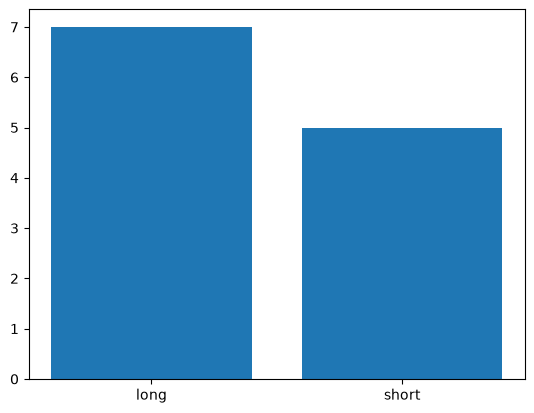

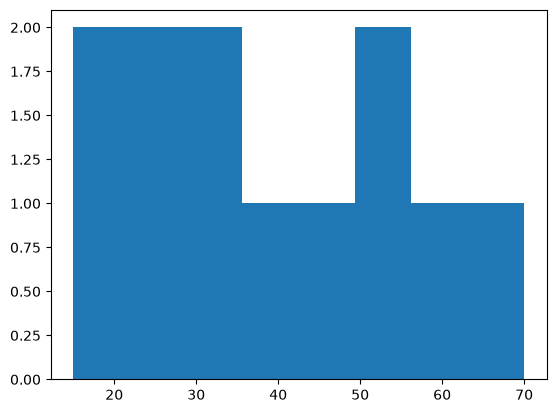

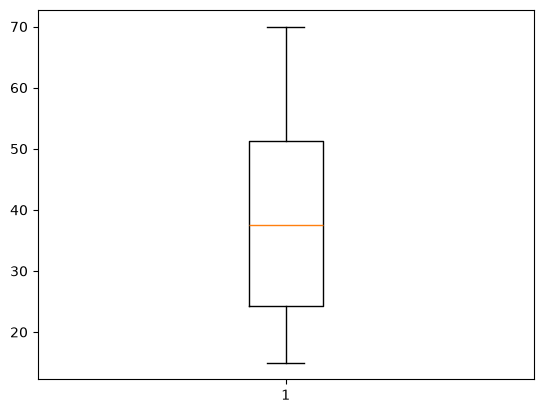

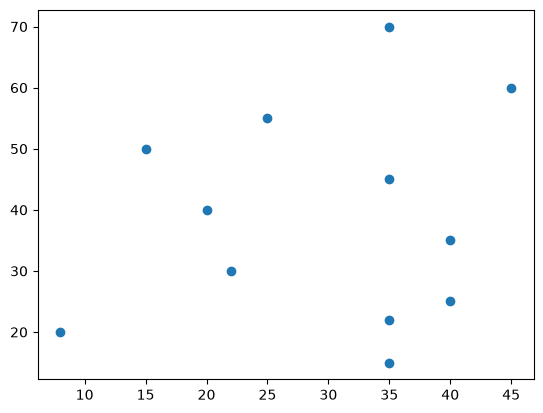

In [ ]:
import matplotlib.pyplot as plt

counts = trips['ride_type'].value_counts()
plt.bar(counts.index, counts.values)
plt.show()

plt.hist(trips['fare'], bins=8)  
plt.show()

plt.boxplot(trips['fare'])
plt.show()

plt.scatter(trips['duration_minutes'], trips['fare'])
plt.show()
